# **Atividade - Perceptron e MLP com scripts programados com PyTorch**


*   **Nome**: Lucas Galvão Wosiach
*   **Matrícula**: 190128828

---

# **Diagnóstico de Diabetes com Redes Neurais**

Nesta atividade, vamos trabalhar com um problema aplicado de **classificação binária**: prever se uma pessoa possui ou não diabetes com base em um conjunto de variáveis clínicas.

[Pima Indians Diabetes Database](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

---

## **Contexto**

- O dataset utilizado é o **Pima Indians Diabetes Dataset**, coletado originalmente pelo Instituto Nacional de Diabetes e Doenças Digestivas e Renais dos Estados Unidos.
- Ele contém registros de mulheres com pelo menos 21 anos de idade da população Pima, um grupo étnico nativo norte-americano com alta incidência de diabetes tipo 2.

## **Objetivo**

O objetivo é treinar uma MLP para prever a presença de diabetes a partir de atributos fisiológicos e laboratoriais.

## **Variáveis de entrada**

Cada observação contém os seguintes atributos:

1. **Pregnancies**, number of times pregnant: Variável discreta.
2. **Glucose**, plasma glucose concentration after 2 hours in an oral glucose tolerance test: Variável contínua.
3. **BloodPressure**, diastolic blood pressure, in mm Hg: Variável contínua.
4. **SkinThickness**, triceps skin fold thickness, in mm: Variável contínua.
5. **Insulin**, 2-hour serum insulin, in μU/mL: Variável contínua.
6. **BMI**, body mass index, weight in kg/(height in m)²: Variável contínua.
7. **DiabetesPedigreeFunction**, family history function: Variável contínua.
8. **Age**, in years: : Variável discreta.

## **Variáveis de saída (Target)**

- **Outcome = 1**: Diabetic
- **Outcome = 0**: Non-diabetic


# **Exercício 1 - Preparação dos dados**

1. Realize tratamento e limpeza de dados caso necessário para treinamento do modelo
2. Crie a matriz de correlação das features e extraia pelo menos um insight estatítstico visível na matriz

```python
import pandas as pd

# URL do dataset
url = "https://raw.githubusercontent.com/pcbrom/perceptron-mlp-cnn/refs/heads/main/data/diabetes.csv"

# Carregar o dataset
df = pd.read_csv(url)
```



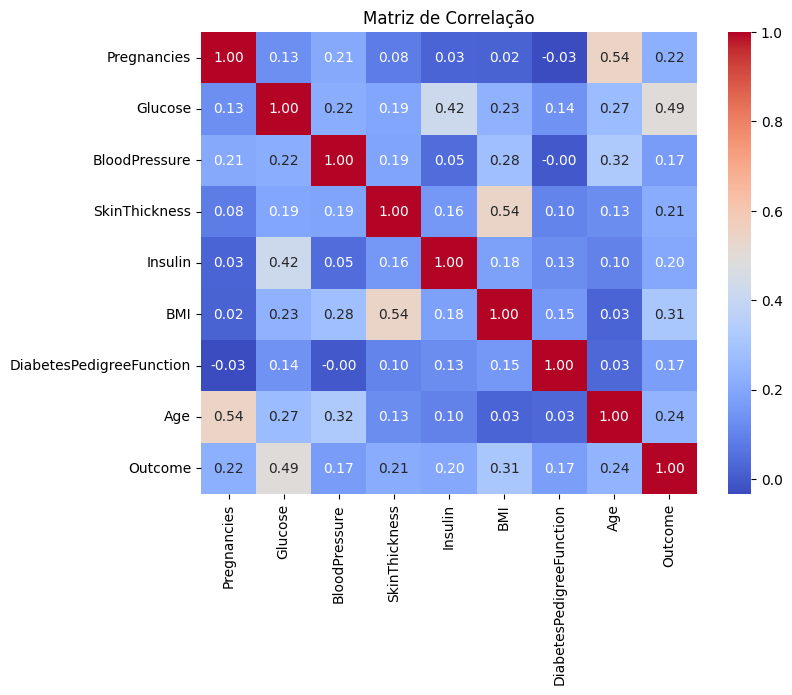

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

# URL do dataset
url = "https://raw.githubusercontent.com/pcbrom/perceptron-mlp-cnn/refs/heads/main/data/diabetes.csv"

# Carregar o dataset
df = pd.read_csv(url)

##### Código Exercício 1 ######

# Colunas Inválidas
ci = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Substitui os 0 por NaN
df[ci] = df[ci].replace(0, np.nan)

# Configura o imputer
imputer = SimpleImputer(missing_values=np.nan, strategy='median')

# Aplica as substituiçoes
df[ci] = imputer.fit_transform(df[ci])

# Calcula a matriz correlaçao
matriz_correlacao = df.corr()

# Printa a matriz correlaçao
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação')
plt.show()

#### Respostas Exercício 1:

A variável Glicose apresentou a maior correlação positiva com a variável Outcome, então dentre as variaveis, ela é o fator que mais se associa a probabilidade de um paciente ser diagnosticado com diabetes


## **Exercício 2 — Comparação de Modelos de Classificação**

### Objetivo
Treinar e comparar dois modelos de classificação supervisionada usando **scikit-learn**:
- **DecisionTreeClassifier**
- **RandomForestClassifier**

O foco é **encontrar a melhor combinação de hiperparâmetros** para cada modelo e **analisar qual apresenta melhor desempenho** nos conjuntos de treino e teste.

---

###  Instruções

1. **Divisão dos dados**
   - Utilize o mesmo dataset do Exercício 1 (já limpo e tratado).  
   - Divida os dados em **80% para treino** e **20% para teste**, de forma **estratificada** para manter a proporção de classes.  
   - Use `train_test_split` do **scikit-learn** com `random_state=42`.

2. **Treinamento dos modelos**
   - Crie dois modelos e os treine utilizando o **conjunto de treino**:
     - `DecisionTreeClassifier`
     - `RandomForestClassifier`

3. **Busca de hiperparâmetros**
   - Utilize **GridSearchCV** para encontrar a melhor combinação de parâmetros para cada modelo.  
   - Varie os seguintes parâmetros:
     - **Decision Tree** → `max_depth`, `min_samples_split`, `min_samples_leaf`, `criterion`.  
     - **Random Forest** → `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`.

4. **Avaliação**
   - Avalie os **melhores modelos** (após o GridSearch) usando o **conjunto de teste**.  
   - Calcule as métricas:
     - **Acurácia**
     - **F1-Score**

5. **Apresentação dos resultados**
   - Monte uma **tabela Markdown** como a seguir:

     ```markdown
     | Modelo | Conjunto | Acurácia | F1-Score |
     |:-------|:----------|----------:|----------:|
     | Decision Tree | Treino | 0.0000 | 0.0000 |
     | Decision Tree | Teste  | 0.0000 | 0.0000 |
     | Random Forest | Treino | 0.0000 | 0.0000 |
     | Random Forest | Teste  | 0.0000 | 0.0000 |
     ```

6. **Análise dos resultados**
   - Responda:
     - a) Qual modelo obteve melhor desempenho? por quê ?.  
     - b) Houve **overfitting**? Como você justificaria a resposta anterior?
     - d) Qual modelo se sobressaiu ? Esse resultado era esperado ? Por quê?



In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# URL do dataset
url = "https://raw.githubusercontent.com/pcbrom/perceptron-mlp-cnn/refs/heads/main/data/diabetes.csv"

# Carregar o dataset
df = pd.read_csv(url)

##### Código Exercício 1 ######

# Colunas Inválidas
ci = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Substitui os 0 por NaN
df[ci] = df[ci].replace(0, np.nan)

# Configura o imputer
imputer = SimpleImputer(missing_values=np.nan, strategy='median')

# Aplica as substituiçoes
df[ci] = imputer.fit_transform(df[ci])

# Calcula a matriz correlaçao
matriz_correlacao = df.corr()

##### Código Exercício 2 ######

# Separar features (x) e target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Modelo 1 - decision tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_params = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Modelo 2 - random forest
rf_model = RandomForestClassifier(random_state=42)
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# Grid search pra ddecision tree
grid_dt = GridSearchCV(
    dt_model,
    dt_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
grid_dt.fit(X_train, y_train)
best_dt = grid_dt.best_estimator_

# Grid search pra random rorest
grid_rf = GridSearchCV(
    rf_model,
    rf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

# Avaliaçao e tabela de resultados
def avaliar_modelo(modelo, X_tr, y_tr, X_te, y_te, nome_modelo):
    """Avalia um modelo nos conjuntos de treino e teste."""
    # Predicts
    y_pred_train = modelo.predict(X_tr)
    y_pred_test = modelo.predict(X_te)

    # Metricas treino
    acc_train = accuracy_score(y_tr, y_pred_train)
    f1_train = f1_score(y_tr, y_pred_train, average='binary')

    # Metricas teste
    acc_test = accuracy_score(y_te, y_pred_test)
    f1_test = f1_score(y_te, y_pred_test, average='binary')

    return [
        {'Modelo': nome_modelo, 'Conjunto': 'Treino', 'Acurácia': acc_train, 'F1-Score': f1_train},
        {'Modelo': nome_modelo, 'Conjunto': 'Teste',  'Acurácia': acc_test,  'F1-Score': f1_test}
    ]

# Salvar resultados
resultados = []
resultados.extend(avaliar_modelo(best_dt, X_train, y_train, X_test, y_test, 'Decision Tree'))
resultados.extend(avaliar_modelo(best_rf, X_train, y_train, X_test, y_test, 'Random Forest'))

# Dataframe pra tabela
df_resultados = pd.DataFrame(resultados)

# Tabela formatada
print("\n" + "=" * 60)
print("RESULTADOS FINAIS")
print("=" * 60)
print(df_resultados.to_markdown(index=False, floatfmt=".4f"))



RESULTADOS FINAIS
| Modelo        | Conjunto   |   Acurácia |   F1-Score |
|:--------------|:-----------|-----------:|-----------:|
| Decision Tree | Treino     |     0.8143 |     0.7635 |
| Decision Tree | Teste      |     0.7597 |     0.6783 |
| Random Forest | Treino     |     0.9674 |     0.9522 |
| Random Forest | Teste      |     0.7532 |     0.6275 |


Respostas Exercício 2

a) O modelo Decision Tree obteve o melhor desempenho. Ao observar o conjunto de teste (que é o que importa para a avaliação real), a Decision Tree superou o Random Forest tanto em Acurácia (75.97% contra 75.32%) quanto, mais significativamente, no F1-Score (0.6783 contra 0.6275). O F1-Score mais alto indica que a árvore de decisão foi muito mais competente em equilibrar a precisão e a sensibilidade ao detectar os casos positivos de diabetes.

b) Sim, houve overfitting claro no modelo Random Forest. Justificativa pelos números:

Random Forest: Apresentou um desempenho quase perfeito no treino (Acurácia de 96.74%), mas caiu drasticamente no teste (75.32%). Essa diferença enorme é a definição clássica de overfitting: o modelo "decorou" os dados de treino, mas não conseguiu generalizar para novos pacientes.

Decision Tree: Apresentou um comportamento muito mais estável. A queda entre treino (81.43%) e teste (75.97%) foi pequena (cerca de 5%), indicando uma boa capacidade de generalização.

c) O modelo que se sobressaiu foi a Decision Tree. Esse resultado não era o esperado teoricamente, pois métodos de Ensemble como o Random Forest costumam ser superiores a árvores únicas.

Isso talvez tenha ocorrido por causa do tamanho do Dataset que é pequeno. O Random Forest é um modelo complexo que geralmente precisa de mais dados para mostrar sua superioridade. Ou talvez por causa do ruído, já que o dataset possui muito ruído. O Random Forest, ao tentar ajustar-se perfeitamente ao treino (chegando a 96%), acabou modelando esse ruído em vez do padrão real.

# **Exercício 3 - Construção MLP**

1. Proponha uma arquiterura de MLP, defina os hiperparâmetros, otimizador, função de perda.
2. Faça a divisão dos dados:
  - 70% para treino
  - 15% para validação
  - 15% para teste
3. Faça o treinamento da rede e apresente:
  - Acurácia no conjunto de teste.
  - Matriz de confusão.
  - Relatório de classificação.
4. Responda:
- a) Houve diferença entre o desempenho no conjunto de validação e no conjunto de teste? Como essa diferença deve ser interpretada?
- b) Como a validação contribui para construção de um modelo mais estável**
- c) Durante o treinamento do seu MLP, qual/quais foram as decisões que mais impactaram o desempenho final do modelo (como número de camadas, taxa de aprendizado, função de ativação ou otimizador)? Reflita sobre como essas escolhas influenciaram o comportamento do erro de treino e validação ao longo das épocas.

**O uso de pytorch é obrigatório para resolução**
```python
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
# --- Acurácia
acc_test = accuracy_score(y_true_test, y_pred_test)
print(f"Acurácia no conjunto de teste: {acc_test:.4f}")

# --- Matriz de confusão
cm = confusion_matrix(y_true_test, y_pred_test)
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão (Teste)')
plt.xlabel('Classe Predita')
plt.ylabel('Classe Real')
plt.tight_layout()
plt.show()

# --- Relatório de classificação
print("\nRelatório de Classificação:")
print(classification_report(y_true_test, y_pred_test, digits=4, zero_division=1))
```

Acurácia no conjunto de teste: 0.7414



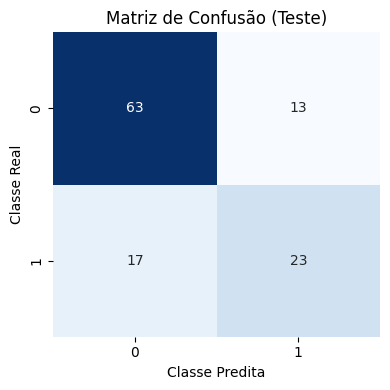


Relatório de Classificação:
              precision    recall  f1-score   support

           0     0.7875    0.8289    0.8077        76
           1     0.6389    0.5750    0.6053        40

    accuracy                         0.7414       116
   macro avg     0.7132    0.7020    0.7065       116
weighted avg     0.7363    0.7414    0.7379       116



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Configurar seed
torch.manual_seed(42)
np.random.seed(42)

# URL do dataset
url = "https://raw.githubusercontent.com/pcbrom/perceptron-mlp-cnn/refs/heads/main/data/diabetes.csv"

# Carregar o dataset
df = pd.read_csv(url)

##### Código Exercício 1 ######

# Colunas Inválidas
ci = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Substitui os 0 por NaN
df[ci] = df[ci].replace(0, np.nan)

# Configura o imputer
imputer = SimpleImputer(missing_values=np.nan, strategy='median')

# Aplica as substituiçoes
df[ci] = imputer.fit_transform(df[ci])

# Calcula a matriz correlaçao na o dataset tratado
matriz_correlacao = df.corr()

##### Código Exercício 2 ######

# Separar features (x) e target (y)
X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values

##### Código Exercício 3 ######

# Divisão pra teste
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)

# Divisão pra validaçao
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42)

# Padronizaçao
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Converter pra tensores pytorch
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

# Arquitetura
class DiabetesMLP(nn.Module):
    def __init__(self):
        super(DiabetesMLP, self).__init__()
        self.layers = nn.Sequential(
            # Camada de Entrada (8 features) -> Oculta 1
            nn.Linear(8, 32),
            nn.ReLU(),
            # Oculta 1 -> Oculta 2
            nn.Linear(32, 16),
            nn.ReLU(),
            # Oculta 2 -> Saída (1 neurônio para classificação binária)
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.layers(x)

# Instanciar modelo
model = DiabetesMLP()

# Hiperparâmetros e Otimizador
learning_rate = 0.01
epochs = 200
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Treinamento
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(epochs):
    model.train()

    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_t)
        val_loss = criterion(val_outputs, y_val_t)

        # Calcular acurácia na validaçao
        val_preds = (torch.sigmoid(val_outputs) > 0.5).float()
        val_acc = (val_preds == y_val_t).float().mean().item()

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    val_accs.append(val_acc)

# Avaliação no Teste
model.eval()
with torch.no_grad():
    y_logits = model(X_test_t)
    y_probs = torch.sigmoid(y_logits)
    y_pred_test = (y_probs > 0.5).float().numpy().flatten()

y_true_test = y_test

# --- Acurácia
acc_test = accuracy_score(y_true_test, y_pred_test)
print(f"Acurácia no conjunto de teste: {acc_test:.4f}\n")

# --- Matriz de confusão
cm = confusion_matrix(y_true_test, y_pred_test)
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão (Teste)')
plt.xlabel('Classe Predita')
plt.ylabel('Classe Real')
plt.tight_layout()
plt.show()

# --- Relatório de classificação
print("\nRelatório de Classificação:")
print(classification_report(y_true_test, y_pred_test, digits=4, zero_division=1))

### Respostas Exercício 3

- a) A diferença é pequena, o que indica que o modelo generaliza bem e não tem overfitting significativo. Ou seja o modelo aprendeu padrões reais dos dados ao invés de só decorar o conjunto de treino

- b) A validação ajuda de 4 formas: Detecta overfitting, ajudar hiperparametro, escolhe o melhor modelo e podemos parar o treino quando a validação para de melhorar

- c) 1. Padronização (StandardScaler):

Essencial para MLPs funcionarem bem, coloca todas as features na mesma escala, e sem isso o modelo não converge direito porque features com valores grandes dominam o gradiente

2. Função de ativação ReLU:

Evita o problema do gradiente desvanecente, deixa o treino mais rápido e permite redes mais profundas

3. Otimizador Adam:

Ajusta o learning rate automaticamente para cada parâmetro, mais robusto e fácil de usar que SGD simples e resulta numa convergência suave sem oscilações

4. Função de perda BCEWithLogitsLoss:

Mais estável numericamente do que aplicar sigmoid + BCELoss separadamente e evita problemas de overflow/underflow


## QA

1. **Considere um modelo de detecção de fraudes em transações financeiras. Nesse contexto, qual métrica deve ser priorizada — *precision* ou *recall* — e por quê? Justifique com base nos efeitos de falsos positivos e falsos negativos.**  
2. **Considere um modelo de triagem médica que identifica pacientes em estado crítico. Nesse caso, qual métrica deve ser priorizada — *precision* ou *recall* — e por quê? Explique os impactos dessa escolha.**  
3. **Um modelo de classificação apresenta previsões sistematicamente enviesadas para uma das classes, independentemente dos dados de entrada. O que esse comportamento indica e quais medidas podem ser tomadas para corrigir o problema?**  
4. **Durante o treinamento de uma rede neural profunda, as camadas iniciais deixam de atualizar seus pesos, apresentando gradientes próximos de zero. Que fenômeno está ocorrendo, quais são suas causas e quais estratégias podem ser aplicadas para solucioná-lo?**  
5. **Um aluno utiliza a função de ativação degrau em todas as camadas de um MLP profundo. Descreva o impacto dessa decisão sobre o processo de aprendizado e compare com o comportamento de uma rede que utiliza a função ReLU.**




### Respostas QA

- 1) Recall, pois no caso do falso negativo, uma fraude não detectada pode causar prejuízo financeiro grande e irreversível, e no caso do falso positivo, uma transação legítima bloqueada causa apenas inconveniência temporária ao cliente. Então é melhor ter mais falsos positivos do que deixar passar fraudes reais. O custo de perder uma fraude é muito maior que o custo de verificar manualmente algumas transações.

- 2) Novamente, o Recall. Na medicina, é fundamental identificar todos os casos críticos, mesmo que isso signifique encaminhar alguns pacientes sem risco de vida para avaliação adicional. Deixar passar um paciente em risco é inaceitável.

- 3) Esse comportamento indica viés do modelo causado possivelmente por:
Desbalanceamento de classes, overfitting à classe majoritária, inicialização ruim dos pesos e/ou learning rate inadequado.

Para corrigir podemos:
Balancear os dados, ajustar os pesos de classe, coletar mais dados, mudar a métrica e estratificar a validação.

- 4) Durante o backpropagation, os gradientes são multiplicados camada por camada. Em redes profundas, gradientes pequenos multiplicados várias vezes resultam em valores muito próximos de zero nas camadas iniciais. Isso faz os pesos dessas camadas pararem de atualizar.
Para solucionar o problema podemos usar ReLU ou variantes, usar batch normalization, usar a ResNet ou reduzir a profundidade da rede

- 5) Se o aluno usar a função degrau, a rede não vai aprender nada, já que para aprender, a rede precisa calcular a inclinação da função. A função degrau é plana, o que significa que sua inclinação é zero. Na matemática da rede neural, multiplicamos o erro pela inclinação. Como a inclinação é zero, o ajuste dos pesos também vira zero, então a rede fica "travada" e nunca evolui. Agora, a função ReLU tem uma inclinação igual a 1 para valores positivosentão como a inclinação não é zero, o sinal de aprendizado consegue passar pelas camadas. Isso permite que a rede calcule como ajustar seus pesos corretamente e aprenda padrões complexos.